## CEAS-08 Dataset, Synthetic with Rewriting

Loading datasets...
Train data: 2000 rows
Test data: 1000 rows
Synthetic data: 1000 rows
Synthetic strong data: 1000 rows
Test set: 1000 samples, 500 malicious
Real malicious: 1000
Real benign: 1000
Synthetic malicious: 1000
Synthetic strong malicious: 1000

EXPERIMENT 1: REAL-WORLD MALICIOUS DATA (1000 BENIGN + VARYING MALICIOUS)

Testing malicious size: 50
  Real malicious: 50
  Real benign: 1000
  Total training: 1050
  Training set: 1050 samples, 50 malicious
  Accuracy: 0.7150
  Precision: 1.0000
  Recall: 0.4300
  F1: 0.6014

Testing malicious size: 100
  Real malicious: 100
  Real benign: 1000
  Total training: 1100
  Training set: 1100 samples, 100 malicious
  Accuracy: 0.8070
  Precision: 1.0000
  Recall: 0.6140
  F1: 0.7608

Testing malicious size: 200
  Real malicious: 200
  Real benign: 1000
  Total training: 1200
  Training set: 1200 samples, 200 malicious
  Accuracy: 0.9060
  Precision: 0.9975
  Recall: 0.8140
  F1: 0.8965

Testing malicious size: 300
  Real malicious: 30

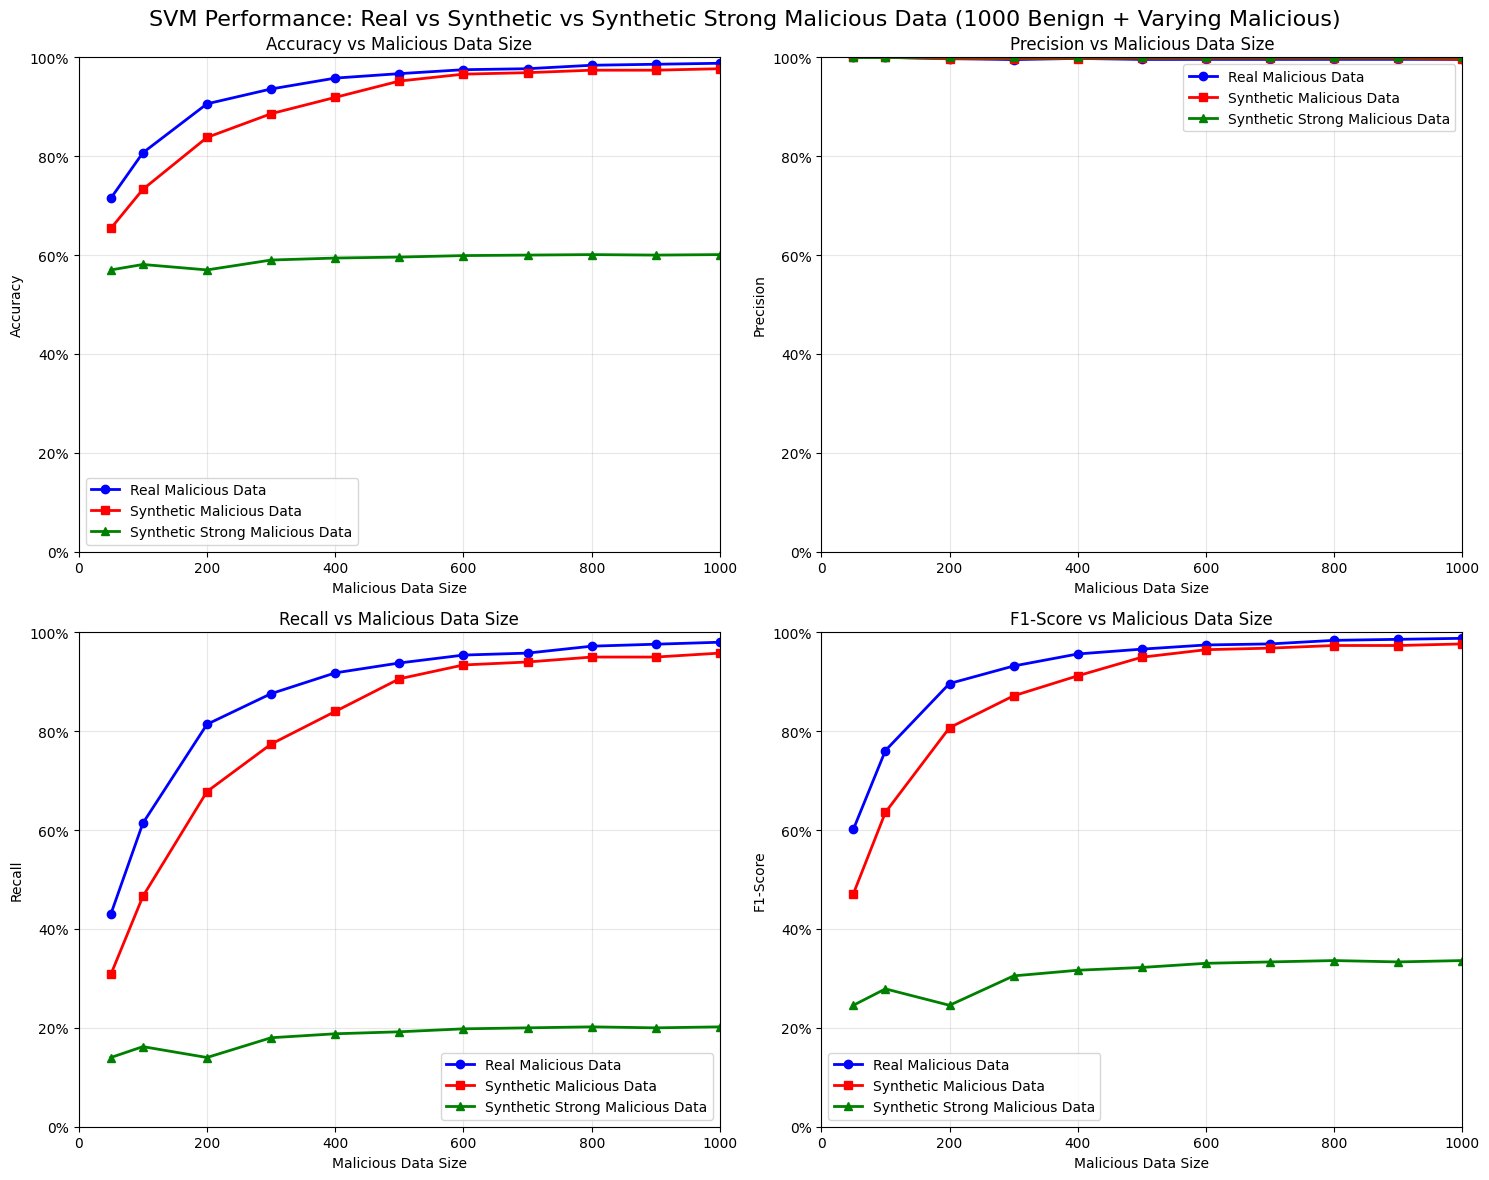


COMPARATIVE ANALYSIS

REAL MALICIOUS DATA:
Best Accuracy: 0.9880 at 1000 malicious samples
Best Precision: 1.0000 at 50 malicious samples
Best Recall: 0.9800 at 1000 malicious samples
Best F1: 0.9879 at 1000 malicious samples

SYNTHETIC MALICIOUS DATA:
Best Accuracy: 0.9770 at 1000 synthetic samples
Best Precision: 1.0000 at 50 synthetic samples
Best Recall: 0.9580 at 1000 synthetic samples
Best F1: 0.9766 at 1000 synthetic samples

SYNTHETIC STRONG MALICIOUS DATA:
Best Accuracy: 0.6010 at 800 synthetic strong samples
Best Precision: 1.0000 at 50 synthetic strong samples
Best Recall: 0.2020 at 800 synthetic strong samples
Best F1: 0.3361 at 800 synthetic strong samples

PERFORMANCE COMPARISON AT KEY SIZES:
Size 100:
  Real F1=0.7608
  Synthetic F1=0.6357 (diff: -0.1251)
  Synthetic Strong F1=0.2788 (diff: -0.4820)
Size 500:
  Real F1=0.9660
  Synthetic F1=0.9497 (diff: -0.0163)
  Synthetic Strong F1=0.3221 (diff: -0.6439)
Size 1000:
  Real F1=0.9879
  Synthetic F1=0.9766 (diff: -0.011

In [1]:
# SVM Classification with Synthetic Data Ratio Analysis
import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# File paths
TRAIN_FILE = "../raw/email_phishing_CEAS-08_train.csv.gz"
TEST_FILE = "../raw/email_phishing_CEAS-08_test.csv.gz"
SYNTHETIC_FILE = "../data/seeds-augment/email_phishing_CEAS-08_train_malicious_rewrite_1K.csv.gz"
SYNTHETIC_STRONG_FILE = "../data/seeds-augment/email_phishing_CEAS-08_train_malicious_rewrite_strong_1K.csv.gz"

# Configuration
FIXED_BENIGN_SIZE = 1000  # Fixed benign data size
MALICIOUS_SIZES = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]  # Varying malicious sizes

print("Loading datasets...")

# Load datasets
def load_data(file_path):
    with gzip.open(file_path, 'rt', encoding='utf-8') as f:
        return pd.read_csv(f)

train_df = load_data(TRAIN_FILE)
test_df = load_data(TEST_FILE)
synthetic_df = load_data(SYNTHETIC_FILE)
synthetic_strong_df = load_data(SYNTHETIC_STRONG_FILE)

print(f"Train data: {len(train_df)} rows")
print(f"Test data: {len(test_df)} rows") 
print(f"Synthetic data: {len(synthetic_df)} rows")
print(f"Synthetic strong data: {len(synthetic_strong_df)} rows")

# Prepare test data
test_df['combined_text'] = test_df['subject'].fillna('') + ' ' + test_df['body'].fillna('')
X_test = test_df['combined_text']
y_test = test_df['label']

print(f"Test set: {len(y_test)} samples, {y_test.sum()} malicious")

# Prepare real and synthetic malicious data
real_malicious = train_df[train_df['label'] == 1].copy()
real_benign = train_df[train_df['label'] == 0].copy()
synthetic_malicious = synthetic_df.copy()  # All synthetic data is malicious
synthetic_strong_malicious = synthetic_strong_df.copy()  # All synthetic strong data is malicious

print(f"Real malicious: {len(real_malicious)}")
print(f"Real benign: {len(real_benign)}")
print(f"Synthetic malicious: {len(synthetic_malicious)}")
print(f"Synthetic strong malicious: {len(synthetic_strong_malicious)}")

# Experiment 1: Real-world malicious data with varying sizes
print("\n" + "="*60)
print("EXPERIMENT 1: REAL-WORLD MALICIOUS DATA (1000 BENIGN + VARYING MALICIOUS)")
print("="*60)

real_results = []

for malicious_size in MALICIOUS_SIZES:
    print(f"\nTesting malicious size: {malicious_size}")
    
    benign_size = FIXED_BENIGN_SIZE
    total_size = malicious_size + benign_size
    
    print(f"  Real malicious: {malicious_size}")
    print(f"  Real benign: {benign_size}")
    print(f"  Total training: {total_size}")
    
    # Sample real data only
    train_samples = []
    
    # Add real malicious samples
    if malicious_size <= len(real_malicious):
        sampled_real_mal = real_malicious.sample(n=malicious_size, random_state=42)
    else:
        sampled_real_mal = real_malicious
    train_samples.append(sampled_real_mal)
    
    # Add benign samples
    if benign_size <= len(real_benign):
        sampled_benign = real_benign.sample(n=benign_size, random_state=42)
    else:
        sampled_benign = real_benign
    train_samples.append(sampled_benign)
    
    # Combine training data
    train_data = pd.concat(train_samples, ignore_index=True)
    train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle
    
    # Prepare training features
    train_data['combined_text'] = train_data['subject'].fillna('') + ' ' + train_data['body'].fillna('')
    X_train = train_data['combined_text']
    y_train = train_data['label']
    
    print(f"  Training set: {len(y_train)} samples, {y_train.sum()} malicious")
    
    # Vectorize text
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    # Train SVM
    svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    svm.fit(X_train_vec, y_train)
    
    # Predict
    y_pred = svm.predict(X_test_vec)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    real_results.append({
        'malicious_size': malicious_size,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1: {f1:.4f}")

# Experiment 2: Synthetic malicious data with varying sizes
print("\n" + "="*60)
print("EXPERIMENT 2: SYNTHETIC MALICIOUS DATA (1000 BENIGN + VARYING SYNTHETIC MALICIOUS)")
print("="*60)

synthetic_results = []

for malicious_size in MALICIOUS_SIZES:
    print(f"\nTesting synthetic malicious size: {malicious_size}")
    
    benign_size = FIXED_BENIGN_SIZE
    total_size = malicious_size + benign_size
    
    print(f"  Synthetic malicious: {malicious_size}")
    print(f"  Real benign: {benign_size}")
    print(f"  Total training: {total_size}")
    
    # Sample data
    train_samples = []
    
    # Add synthetic malicious samples
    if malicious_size <= len(synthetic_malicious):
        sampled_synthetic = synthetic_malicious.sample(n=malicious_size, random_state=42)
    else:
        sampled_synthetic = synthetic_malicious
    train_samples.append(sampled_synthetic)
    
    # Add real benign samples
    if benign_size <= len(real_benign):
        sampled_benign = real_benign.sample(n=benign_size, random_state=42)
    else:
        sampled_benign = real_benign
    train_samples.append(sampled_benign)
    
    # Combine training data
    train_data = pd.concat(train_samples, ignore_index=True)
    train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle
    
    # Prepare training features
    train_data['combined_text'] = train_data['subject'].fillna('') + ' ' + train_data['body'].fillna('')
    X_train = train_data['combined_text']
    y_train = train_data['label']
    
    print(f"  Training set: {len(y_train)} samples, {y_train.sum()} malicious")
    
    # Vectorize text
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    # Train SVM
    svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    svm.fit(X_train_vec, y_train)
    
    # Predict
    y_pred = svm.predict(X_test_vec)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    synthetic_results.append({
        'malicious_size': malicious_size,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1: {f1:.4f}")

# Experiment 3: Synthetic strong malicious data with varying sizes
print("\n" + "="*60)
print("EXPERIMENT 3: SYNTHETIC STRONG MALICIOUS DATA (1000 BENIGN + VARYING SYNTHETIC STRONG MALICIOUS)")
print("="*60)

synthetic_strong_results = []

for malicious_size in MALICIOUS_SIZES:
    print(f"\nTesting synthetic strong malicious size: {malicious_size}")
    
    benign_size = FIXED_BENIGN_SIZE
    total_size = malicious_size + benign_size
    
    print(f"  Synthetic strong malicious: {malicious_size}")
    print(f"  Real benign: {benign_size}")
    print(f"  Total training: {total_size}")
    
    # Sample data
    train_samples = []
    
    # Add synthetic strong malicious samples
    if malicious_size <= len(synthetic_strong_malicious):
        sampled_synthetic_strong = synthetic_strong_malicious.sample(n=malicious_size, random_state=42)
    else:
        sampled_synthetic_strong = synthetic_strong_malicious
    train_samples.append(sampled_synthetic_strong)
    
    # Add real benign samples
    if benign_size <= len(real_benign):
        sampled_benign = real_benign.sample(n=benign_size, random_state=42)
    else:
        sampled_benign = real_benign
    train_samples.append(sampled_benign)
    
    # Combine training data
    train_data = pd.concat(train_samples, ignore_index=True)
    train_data = train_data.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle
    
    # Prepare training features
    train_data['combined_text'] = train_data['subject'].fillna('') + ' ' + train_data['body'].fillna('')
    X_train = train_data['combined_text']
    y_train = train_data['label']
    
    print(f"  Training set: {len(y_train)} samples, {y_train.sum()} malicious")
    
    # Vectorize text
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    # Train SVM
    svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    svm.fit(X_train_vec, y_train)
    
    # Predict
    y_pred = svm.predict(X_test_vec)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    synthetic_strong_results.append({
        'malicious_size': malicious_size,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1: {f1:.4f}")

# Convert results to DataFrames
real_results_df = pd.DataFrame(real_results)
synthetic_results_df = pd.DataFrame(synthetic_results)
synthetic_strong_results_df = pd.DataFrame(synthetic_strong_results)

print("\n" + "="*50)
print("REAL-WORLD MALICIOUS DATA RESULTS")
print("="*50)
print(real_results_df)

print("\n" + "="*50)
print("SYNTHETIC MALICIOUS DATA RESULTS")
print("="*50)
print(synthetic_results_df)

print("\n" + "="*50)
print("SYNTHETIC STRONG MALICIOUS DATA RESULTS")
print("="*50)
print(synthetic_strong_results_df)

# Plot comparative results with three lines
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('SVM Performance: Real vs Synthetic vs Synthetic Strong Malicious Data (1000 Benign + Varying Malicious)', fontsize=16)

metrics = ['accuracy', 'precision', 'recall', 'f1']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i//2, i%2]
    
    # Plot real malicious data curve
    ax.plot(real_results_df['malicious_size'], real_results_df[metric], 
            'o-', linewidth=2, markersize=6, label='Real Malicious Data', color='blue')
    
    # Plot synthetic malicious data curve
    ax.plot(synthetic_results_df['malicious_size'], synthetic_results_df[metric], 
            's-', linewidth=2, markersize=6, label='Synthetic Malicious Data', color='red')
    
    # Plot synthetic strong malicious data curve
    ax.plot(synthetic_strong_results_df['malicious_size'], synthetic_strong_results_df[metric], 
            '^-', linewidth=2, markersize=6, label='Synthetic Strong Malicious Data', color='green')
    
    ax.set_xlabel('Malicious Data Size')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs Malicious Data Size')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1000)
    ax.set_ylim(0, 1)  # Scale y-axis from 0% to 100%
    ax.legend()
    
    # Format y-axis as percentage
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("COMPARATIVE ANALYSIS")
print("="*60)

print("\nREAL MALICIOUS DATA:")
print(f"Best Accuracy: {real_results_df['accuracy'].max():.4f} at {real_results_df.loc[real_results_df['accuracy'].idxmax(), 'malicious_size']} malicious samples")
print(f"Best Precision: {real_results_df['precision'].max():.4f} at {real_results_df.loc[real_results_df['precision'].idxmax(), 'malicious_size']} malicious samples")
print(f"Best Recall: {real_results_df['recall'].max():.4f} at {real_results_df.loc[real_results_df['recall'].idxmax(), 'malicious_size']} malicious samples")
print(f"Best F1: {real_results_df['f1'].max():.4f} at {real_results_df.loc[real_results_df['f1'].idxmax(), 'malicious_size']} malicious samples")

print("\nSYNTHETIC MALICIOUS DATA:")
print(f"Best Accuracy: {synthetic_results_df['accuracy'].max():.4f} at {synthetic_results_df.loc[synthetic_results_df['accuracy'].idxmax(), 'malicious_size']} synthetic samples")
print(f"Best Precision: {synthetic_results_df['precision'].max():.4f} at {synthetic_results_df.loc[synthetic_results_df['precision'].idxmax(), 'malicious_size']} synthetic samples")
print(f"Best Recall: {synthetic_results_df['recall'].max():.4f} at {synthetic_results_df.loc[synthetic_results_df['recall'].idxmax(), 'malicious_size']} synthetic samples")
print(f"Best F1: {synthetic_results_df['f1'].max():.4f} at {synthetic_results_df.loc[synthetic_results_df['f1'].idxmax(), 'malicious_size']} synthetic samples")

print("\nSYNTHETIC STRONG MALICIOUS DATA:")
print(f"Best Accuracy: {synthetic_strong_results_df['accuracy'].max():.4f} at {synthetic_strong_results_df.loc[synthetic_strong_results_df['accuracy'].idxmax(), 'malicious_size']} synthetic strong samples")
print(f"Best Precision: {synthetic_strong_results_df['precision'].max():.4f} at {synthetic_strong_results_df.loc[synthetic_strong_results_df['precision'].idxmax(), 'malicious_size']} synthetic strong samples")
print(f"Best Recall: {synthetic_strong_results_df['recall'].max():.4f} at {synthetic_strong_results_df.loc[synthetic_strong_results_df['recall'].idxmax(), 'malicious_size']} synthetic strong samples")
print(f"Best F1: {synthetic_strong_results_df['f1'].max():.4f} at {synthetic_strong_results_df.loc[synthetic_strong_results_df['f1'].idxmax(), 'malicious_size']} synthetic strong samples")

# Performance comparison at specific sizes
print("\nPERFORMANCE COMPARISON AT KEY SIZES:")
for size in [100, 500, 1000]:
    if (size in real_results_df['malicious_size'].values and 
        size in synthetic_results_df['malicious_size'].values and 
        size in synthetic_strong_results_df['malicious_size'].values):
        
        real_f1 = real_results_df[real_results_df['malicious_size'] == size]['f1'].iloc[0]
        synthetic_f1 = synthetic_results_df[synthetic_results_df['malicious_size'] == size]['f1'].iloc[0]
        synthetic_strong_f1 = synthetic_strong_results_df[synthetic_strong_results_df['malicious_size'] == size]['f1'].iloc[0]
        
        diff_synthetic = synthetic_f1 - real_f1
        diff_strong = synthetic_strong_f1 - real_f1
        
        print(f"Size {size}:")
        print(f"  Real F1={real_f1:.4f}")
        print(f"  Synthetic F1={synthetic_f1:.4f} (diff: {diff_synthetic:+.4f})")
        print(f"  Synthetic Strong F1={synthetic_strong_f1:.4f} (diff: {diff_strong:+.4f})")